In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import random
from tqdm import tqdm
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.python.ops.numpy_ops import np_utils
from tensorflow.keras.utils import to_categorical


2026-01-07 02:37:17.496939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767753437.510154      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767753437.514089      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 02:37:17.530478: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
train_dir = '../input/petfinder-pawpularity-score/train'
test_dir = '../input/petfinder-pawpularity-score/test'


(720, 405, 3)


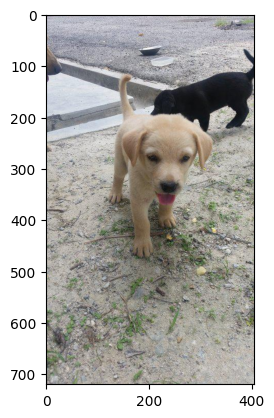

In [4]:
path0='../input/petfinder-pawpularity-score/train/0007de18844b0dbbb5e1f607da0606e0.jpg'
image=cv2.imread(path0)
print(image.shape)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))


(60, 60, 3)


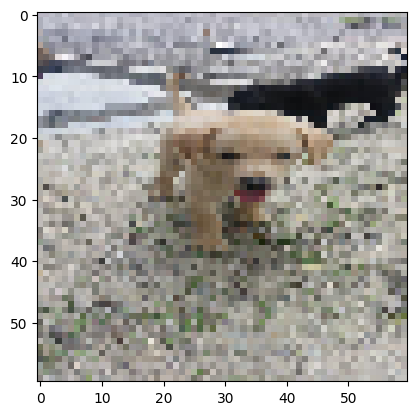

In [5]:
image2=cv2.resize(image,dsize=(60,60),interpolation=cv2.INTER_CUBIC)
print(image2.shape)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))


In [6]:
train=pd.read_csv('../input/petfinder-pawpularity-score/train.csv')
train


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8915,ee97d86d26506239666d3679ff4a73aa,0,0,1,1,0,0,0,0,0,0,0,1,31
8916,7cf13d655a8d0d6a1d636c3920d49e86,0,0,1,1,0,0,0,0,0,0,0,0,33
8917,547e443edbf94b3646ff110324846bae,0,1,1,0,0,0,1,0,0,0,0,0,27
8918,fe2b587f649b9780900246c4b174a231,0,1,1,1,0,0,1,0,0,0,0,0,27


In [7]:
train['Pawpularity'].unique()


array([ 55, 100,  27,  51,  48,  32,  25,  36,  34,  60,  10,  26,  14,
         3,  31,  21,  39,  22,  30,  38,  29,  90,  37,  40,  28,  20,
        42,   7,  15,  24,  79,  59,  12,  41,  85,  65,  43,  16,  35,
        52,  62,  80,  53,  75,  66,  23,  47,  13,   5,  19,  64,  45,
        49,  33,  18,  71,  50,  11,  91,  57,  76,  63,  17,  98,  61,
        67,   8,  46,   2,  54,  68,  89,  58,  73,  44,   4,  56,  88,
        72,  83,  95,  92,  77,  78,   9,  96,  70,  69,   6,  86,  81,
        87,  82,  97,   1,  84,  94,  74,  93,  99])

In [8]:
N0=list(range(100)) 
N1=list(range(1,101)) 
normal_mapping=dict(zip(N1,N0)) 
reverse_mapping=dict(zip(N0,N1)) 


In [9]:
train[train['Id']=='0007de18844b0dbbb5e1f607da0606e0']['Pawpularity'].tolist()[0]


63

In [10]:
trainimg0=[]
trainlabel0=[]
for im in tqdm(os.listdir(train_dir)):
    image=cv2.imread(os.path.join(train_dir,im))
    image2=cv2.resize(image,dsize=(60,60),interpolation=cv2.INTER_CUBIC)
    trainimg0+=[image2]
    trainlabel0+=[train[train['Id']==im[0:-4]]['Pawpularity'].tolist()[0]]


 72%|███████▏  | 6417/8921 [00:20<00:08, 309.65it/s]


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [11]:
trainlabel1=pd.Series(trainlabel0).map(normal_mapping)


In [12]:
trainimg=np.array(trainimg0)
trainlabel=np.array(trainlabel1)


In [13]:
m=len(trainimg)
M=list(range(m))
random.seed(2021)
random.shuffle(M)


In [14]:
trainX=trainimg[M[0:(m//4)*3]]
trainY0=trainlabel[M[0:(m//4)*3]]

testX=trainimg[M[(m//4)*3:]]
testY0=trainlabel[M[(m//4)*3:]]


In [15]:
labels1=to_categorical(trainY0)
trainY=np.array(labels1)


In [16]:
trainx,testx,trainy,testy=train_test_split(trainX,trainY,test_size=0.2,random_state=44)


In [17]:
print(trainx.shape)
print(testx.shape)
print(trainy.shape)
print(testy.shape)


(3849, 60, 60, 3)
(963, 60, 60, 3)
(3849, 100)
(963, 100)


In [18]:
model = Sequential()
model.add(Conv2D(32,(4,4),input_shape = (60,60,3),activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(400, activation='relu'))
model.add(Dense(100, activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 02:37:45.518136: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767753465.518605      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [19]:
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])


In [20]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 57, 57, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 400)            │     4,326,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        40,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,964 (16.73 MB)

 Trainable params: 4,386,964 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
his = model.fit(trainx, trainy, validation_split=0.2, epochs=30, batch_size=92, verbose=2)


Epoch 1/30


I0000 00:00:1767753466.878693      71 service.cc:148] XLA service 0x7fbfa4012fd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767753466.878723      71 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 02:37:46.898796: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767753466.992135      71 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-01-07 02:37:47.816548: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_640_0', 1044 bytes spill stores, 732 bytes spill loads

2026-01-07 02:37:48.039591: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_640', 28 bytes spi

34/34 - 14s - 418ms/step - accuracy: 0.0195 - loss: 25.4846 - val_accuracy: 0.0273 - val_loss: 4.3681
Epoch 2/30
34/34 - 0s - 5ms/step - accuracy: 0.0896 - loss: 4.0812 - val_accuracy: 0.0208 - val_loss: 4.3612
Epoch 3/30
34/34 - 0s - 5ms/step - accuracy: 0.2040 - loss: 3.4670 - val_accuracy: 0.0286 - val_loss: 4.6524
Epoch 4/30
34/34 - 0s - 4ms/step - accuracy: 0.4313 - loss: 2.3973 - val_accuracy: 0.0338 - val_loss: 5.4587
Epoch 5/30
34/34 - 0s - 4ms/step - accuracy: 0.6635 - loss: 1.4575 - val_accuracy: 0.0338 - val_loss: 6.5965
Epoch 6/30
34/34 - 0s - 5ms/step - accuracy: 0.7921 - loss: 0.8742 - val_accuracy: 0.0273 - val_loss: 7.1982
Epoch 7/30
34/34 - 0s - 5ms/step - accuracy: 0.8620 - loss: 0.5628 - val_accuracy: 0.0195 - val_loss: 7.9475
Epoch 8/30
34/34 - 0s - 4ms/step - accuracy: 0.9019 - loss: 0.4114 - val_accuracy: 0.0234 - val_loss: 8.8262
Epoch 9/30
34/34 - 0s - 9ms/step - accuracy: 0.9272 - loss: 0.3279 - val_accuracy: 0.0234 - val_loss: 8.2168
Epoch 10/30
34/34 - 0s - 4

In [22]:
y_pred=model.predict(testx)
pred=np.argmax(y_pred,axis=1)
ground = np.argmax(testy,axis=1)
print(classification_report(ground,pred))


2026-01-07 02:38:05.965051: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 508 bytes spill stores, 544 bytes spill loads



 1/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step

2026-01-07 02:38:07.702010: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 304 bytes spill stores, 388 bytes spill loads



31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00        10
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         7
          15       0.00      0.00      0.00        11
          16       0.00      0.00      0.00         7
          17       0.00      0.00      0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.

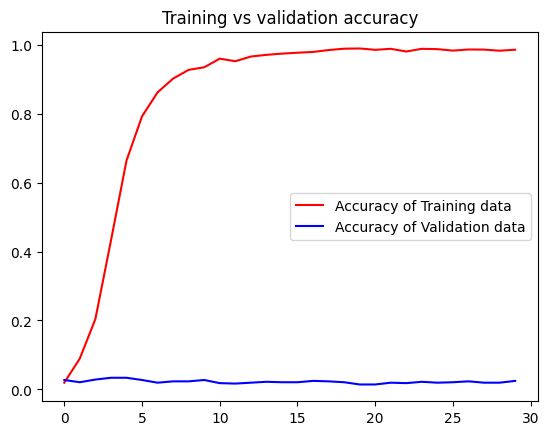

<Figure size 640x480 with 0 Axes>

In [23]:
get_acc = his.history['accuracy']
value_acc = his.history['val_accuracy']
get_loss = his.history['loss']
validation_loss = his.history['val_loss']

epochs = range(len(get_acc))
plt.plot(epochs, get_acc, 'r', label='Accuracy of Training data')
plt.plot(epochs, value_acc, 'b', label='Accuracy of Validation data')
plt.title('Training vs validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()


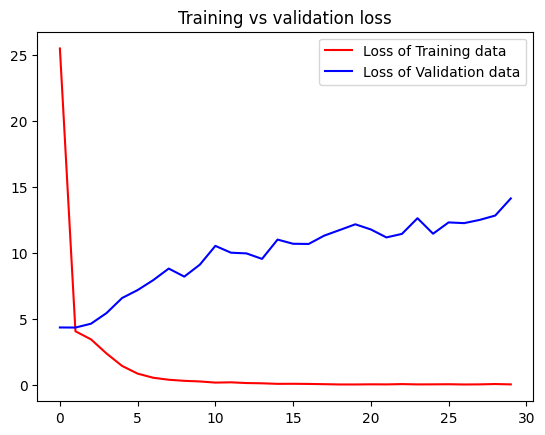

<Figure size 640x480 with 0 Axes>

In [24]:
epochs = range(len(get_loss))
plt.plot(epochs, get_loss, 'r', label='Loss of Training data')
plt.plot(epochs, validation_loss, 'b', label='Loss of Validation data')
plt.title('Training vs validation loss')
plt.legend(loc=0)
plt.figure()
plt.show()


In [25]:
pred2=model.predict(testX)
print(pred2.shape)

PRED=[]
for item in pred2:
    value2=np.argmax(item)      
    PRED+=[value2]
print(pd.Series(PRED).value_counts())


 1/51 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

2026-01-07 02:38:09.141617: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 304 bytes spill stores, 388 bytes spill loads



51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
(1605, 100)
99    133
29    123
45    101
35     97
28     64
     ... 
64      1
93      1
10      1
76      1
74      1
Name: count, Length: 81, dtype: int64


In [26]:
ANS=testY0
print(pd.Series(ANS).value_counts())
accuracy=accuracy_score(ANS,PRED)
print(accuracy)


28    59
30    54
27    49
25    47
99    46
      ..
94     2
95     2
0      2
91     2
81     1
Name: count, Length: 97, dtype: int64
0.020560747663551402


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


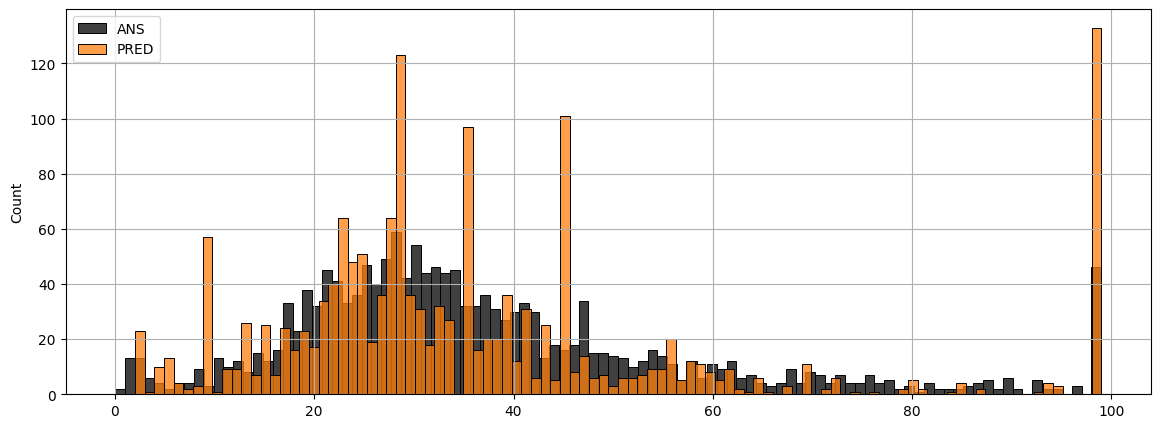

In [27]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(14,5))
sns.histplot(ANS,label='ANS',ax=ax,color='black',bins=100)
sns.histplot(PRED,label='PRED',ax=ax,color='C1',bins=100)
ax.legend()
ax.grid()
plt.show()


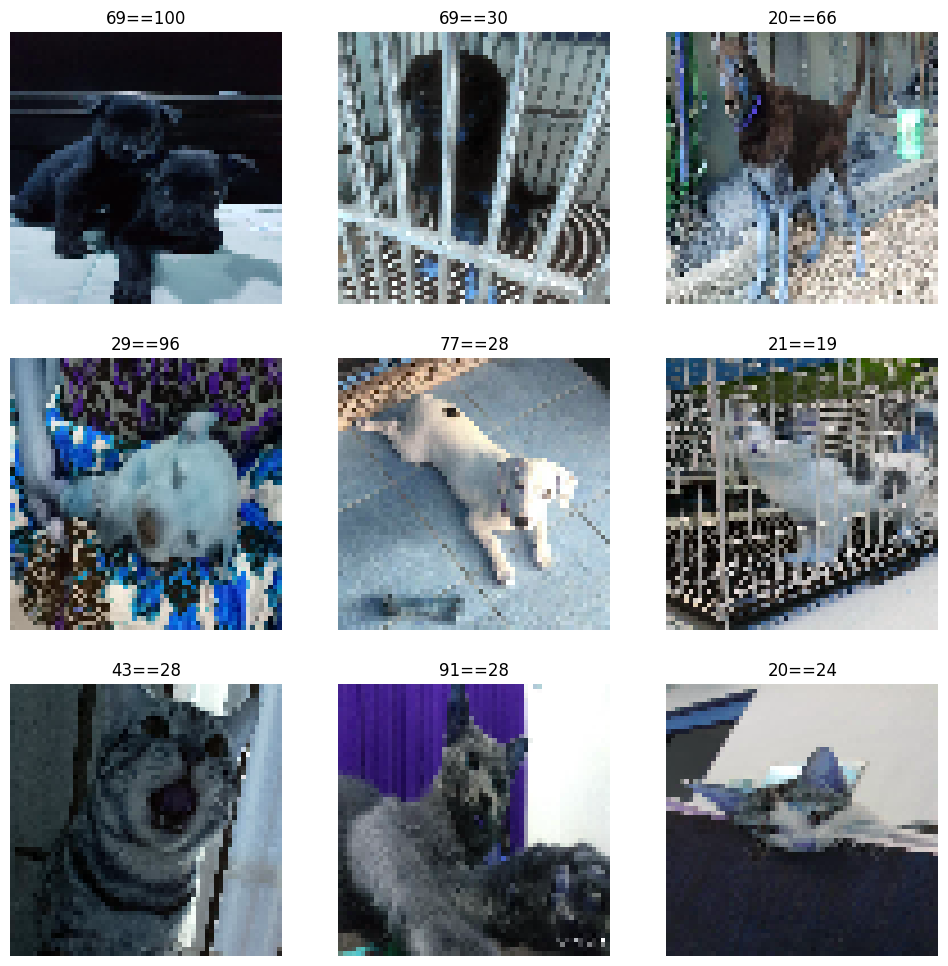

In [28]:
fig, axs = plt.subplots(3,3,figsize=(12,12))
for i in range(9):
    r=i//3
    c=i%3
    img1 = testX[i]
    ax=axs[r][c].axis("off")
    actual=reverse_mapping[testY0[i]]
    predict=reverse_mapping[PRED[i]]    
    ax=axs[r][c].set_title(str(actual)+'=='+str(predict))
    ax=axs[r][c].imshow(img1)
plt.show()


In [29]:
TESTX=[]
testim=[]
for im in tqdm(os.listdir(test_dir)):
    image=cv2.imread(os.path.join(test_dir,im))
    image2=cv2.resize(image,dsize=(60,60),interpolation=cv2.INTER_CUBIC)
    TESTX+=[image2]
    testim+=[im[0:-4]]


 76%|███████▋  | 758/993 [00:01<00:00, 453.41it/s]


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [30]:
TESTX=np.array(TESTX)
print(TESTX.shape)


(758, 60, 60, 3)


In [31]:
test_pred2=model.predict(TESTX)

TESTPRED=[]
for item in test_pred2:
    value=np.argmax(item)      
    value2=reverse_mapping[value]
    TESTPRED+=[float(value2)]
print(pd.Series(TESTPRED).value_counts())


 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

2026-01-07 02:38:12.837664: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 536 bytes spill stores, 600 bytes spill loads



24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
100.0    63
30.0     63
36.0     52
46.0     40
26.0     31
         ..
65.0      1
64.0      1
62.0      1
92.0      1
8.0       1
Name: count, Length: 78, dtype: int64


In [32]:
sample=pd.read_csv('../input/petfinder-pawpularity-score/sample_submission.csv')
sample


,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,64.06
1,caddfb3f8bff9c4b95dbe022018eea21,27.71
2,582eeabd4a448a53ebb79995888a4b0b,5.06
3,afc1ad7f0c5eea880759d09e77f7deee,2.64
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,81.51
...,...,...
987,46bcb1c4ca0b78c584d7a65e1b4b2590,8.30
988,8064261ce5f7197fdc849641b3192eef,68.64
989,a5ff4923e393fa08e67da31c7eb4edd5,80.13
990,fa6a53f962225c17b22392748f91f9ac,64.54


In [33]:
result=pd.DataFrame(testim)
result[1]=TESTPRED
result.columns=['Id','Pawpularity']
result2=result.sort_values('Id')
result2


,Id,Pawpularity
53,0049cb81313c94fa007286e9039af910,36.0
497,0075ec6503412f21cf65ac5f43d80440,42.0
366,0085bfb9a7ebfd776cb804d8b456bb05,46.0
141,00d1cb2ec8b263ae076ff95cae513a88,3.0
415,00d560ebe5e1b2450eb530a2c96d08a3,36.0
...,...,...
146,fedc15d62dc32573834e485a7a7640c8,24.0
68,fefa3692ed2a333d8bc9873054159578,46.0
538,ff31c2bc7cf296899ce28a809600e20e,100.0
537,ff602c36a58c20d88fd0f543fd671040,42.0


In [34]:
result2.to_csv('submission.csv',index=False)
